# 05. Baseline Robustness Evaluation

Notebook này ghi lại kết quả của **Stage 5 — Baseline Robustness Evaluation**.

Vai trò của notebook:

- Không train lại baseline.
- Không sinh lại noisy test.
- Chỉ đọc output đã sinh ra từ `scripts/evaluate_baseline_robustness.py`.
- Phân tích mức giảm hiệu năng của baseline trên các biến thể clean/noisy.
- Ghi lại mốc so sánh trước khi fine-tune và đánh giá PhoBERT.

Nguyên tắc đánh giá:

```text
- Baseline được train trên clean train set.
- Evaluation chạy trên clean/noisy test variants.
- Macro-F1 là metric chính vì dữ liệu mất cân bằng.
- Robustness drop được tính so với clean test của cùng model và cùng task.
```

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

print("Project root:", ROOT)

TABLES_DIR = ROOT / "outputs" / "tables"
FIGURES_DIR = ROOT / "outputs" / "figures"
PREDICTIONS_DIR = ROOT / "outputs" / "predictions"
REPORTS_DIR = ROOT / "outputs" / "reports"
METRICS_DIR = ROOT / "outputs" / "metrics"

Project root: d:\project-ml-engineering\viedufeedback-robust


## 2. Kiểm tra output bắt buộc

Các file này phải tồn tại sau khi chạy:

```powershell
python scripts/evaluate_baseline_robustness.py
```

In [2]:
required_files = {
    "robustness_results": TABLES_DIR / "baseline_robustness_results.csv",
    "robustness_drop": TABLES_DIR / "baseline_robustness_drop.csv",
    "class_report": TABLES_DIR / "baseline_robustness_class_report.csv",
    "predictions": PREDICTIONS_DIR / "baseline_robustness_predictions.csv",
    "metrics_json": METRICS_DIR / "baseline_robustness_results.json",
    "report": REPORTS_DIR / "baseline_robustness_report.md",
    "macro_f1_sentiment": FIGURES_DIR / "baseline_robustness_macro_f1_sentiment.png",
    "macro_f1_topic": FIGURES_DIR / "baseline_robustness_macro_f1_topic.png",
    "macro_f1_drop_sentiment": FIGURES_DIR / "baseline_robustness_macro_f1_drop_sentiment.png",
    "macro_f1_drop_topic": FIGURES_DIR / "baseline_robustness_macro_f1_drop_topic.png",
}

check_df = pd.DataFrame(
    [{"name": name, "path": str(path), "exists": path.exists()} for name, path in required_files.items()]
)

display(check_df)

missing = check_df.loc[~check_df["exists"], "name"].tolist()
if missing:
    raise FileNotFoundError(f"Missing required Stage 5 files: {missing}")

print("All required Stage 5 files exist.")

,name,path,exists
0,robustness_results,d:\project-ml-engineering\viedufeedback-robust...,True
1,robustness_drop,d:\project-ml-engineering\viedufeedback-robust...,True
2,class_report,d:\project-ml-engineering\viedufeedback-robust...,True
3,predictions,d:\project-ml-engineering\viedufeedback-robust...,True
4,metrics_json,d:\project-ml-engineering\viedufeedback-robust...,True
5,report,d:\project-ml-engineering\viedufeedback-robust...,True
6,macro_f1_sentiment,d:\project-ml-engineering\viedufeedback-robust...,True
7,macro_f1_topic,d:\project-ml-engineering\viedufeedback-robust...,True
8,macro_f1_drop_sentiment,d:\project-ml-engineering\viedufeedback-robust...,True
9,macro_f1_drop_topic,d:\project-ml-engineering\viedufeedback-robust...,True


All required Stage 5 files exist.


## 3. Load kết quả

In [3]:
results_df = pd.read_csv(TABLES_DIR / "baseline_robustness_results.csv")
drop_df = pd.read_csv(TABLES_DIR / "baseline_robustness_drop.csv")
class_report_df = pd.read_csv(TABLES_DIR / "baseline_robustness_class_report.csv")

display(results_df.head())
display(drop_df.head())
display(class_report_df.head())

,task,model,variant,noise_type,noise_level,num_samples,accuracy,macro_f1,weighted_f1
0,sentiment,majority,clean,clean,none,3166,0.502211,0.222876,0.335793
1,sentiment,majority,mixed_light,mixed,light,3166,0.502211,0.222876,0.335793
2,sentiment,majority,mixed_no_accent,mixed,medium,3166,0.502211,0.222876,0.335793
3,sentiment,majority,no_accent,remove_diacritics,medium,3166,0.502211,0.222876,0.335793
4,sentiment,majority,teencode_light,teencode,light,3166,0.502211,0.222876,0.335793


,task,model,variant,noise_type,noise_level,clean_accuracy,variant_accuracy,accuracy_drop,accuracy_relative_drop_percent,clean_macro_f1,variant_macro_f1,macro_f1_drop,macro_f1_relative_drop_percent,clean_weighted_f1,variant_weighted_f1,weighted_f1_drop,weighted_f1_relative_drop_percent
0,sentiment,majority,clean,clean,none,0.502211,0.502211,0.0,0.0,0.222876,0.222876,0.0,0.0,0.335793,0.335793,0.0,0.0
1,sentiment,majority,mixed_light,mixed,light,0.502211,0.502211,0.0,0.0,0.222876,0.222876,0.0,0.0,0.335793,0.335793,0.0,0.0
2,sentiment,majority,mixed_no_accent,mixed,medium,0.502211,0.502211,0.0,0.0,0.222876,0.222876,0.0,0.0,0.335793,0.335793,0.0,0.0
3,sentiment,majority,no_accent,remove_diacritics,medium,0.502211,0.502211,0.0,0.0,0.222876,0.222876,0.0,0.0,0.335793,0.335793,0.0,0.0
4,sentiment,majority,teencode_light,teencode,light,0.502211,0.502211,0.0,0.0,0.222876,0.222876,0.0,0.0,0.335793,0.335793,0.0,0.0


,task,model,variant,label,precision,recall,f1_score,support
0,sentiment,majority,clean,negative,0.000000,0.000000,0.000000,1409.0
1,sentiment,majority,clean,neutral,0.000000,0.000000,0.000000,167.0
2,sentiment,majority,clean,positive,0.502211,1.000000,0.668629,1590.0
3,sentiment,majority,clean,accuracy,NaN,NaN,0.502211,NaN
4,sentiment,majority,clean,macro avg,0.167404,0.333333,0.222876,3166.0


## 4. Macro-F1 theo variant

Mục tiêu: xem baseline thay đổi thế nào khi test text bị nhiễu.

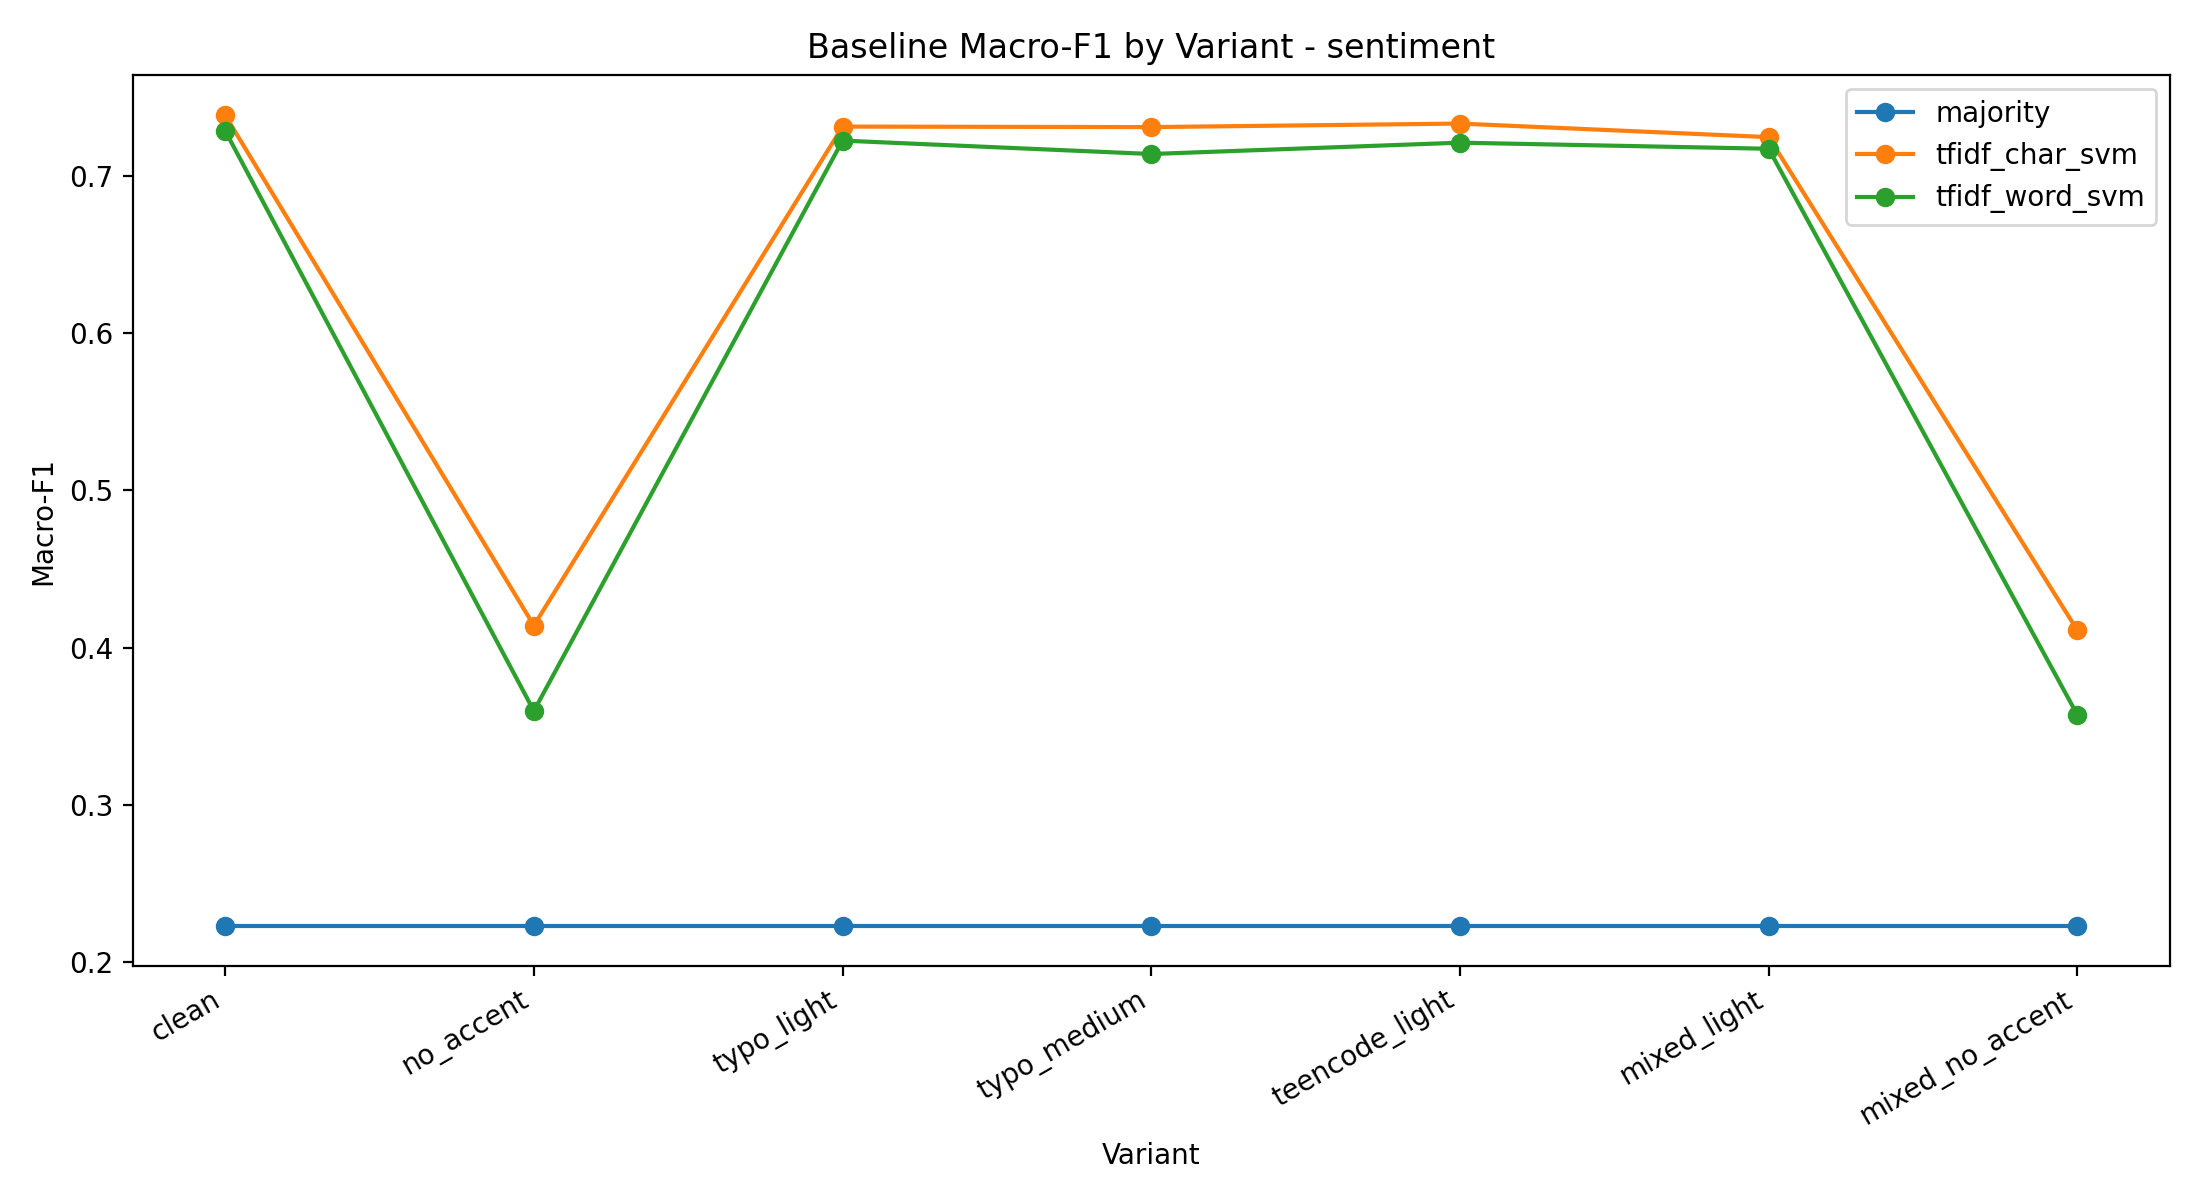

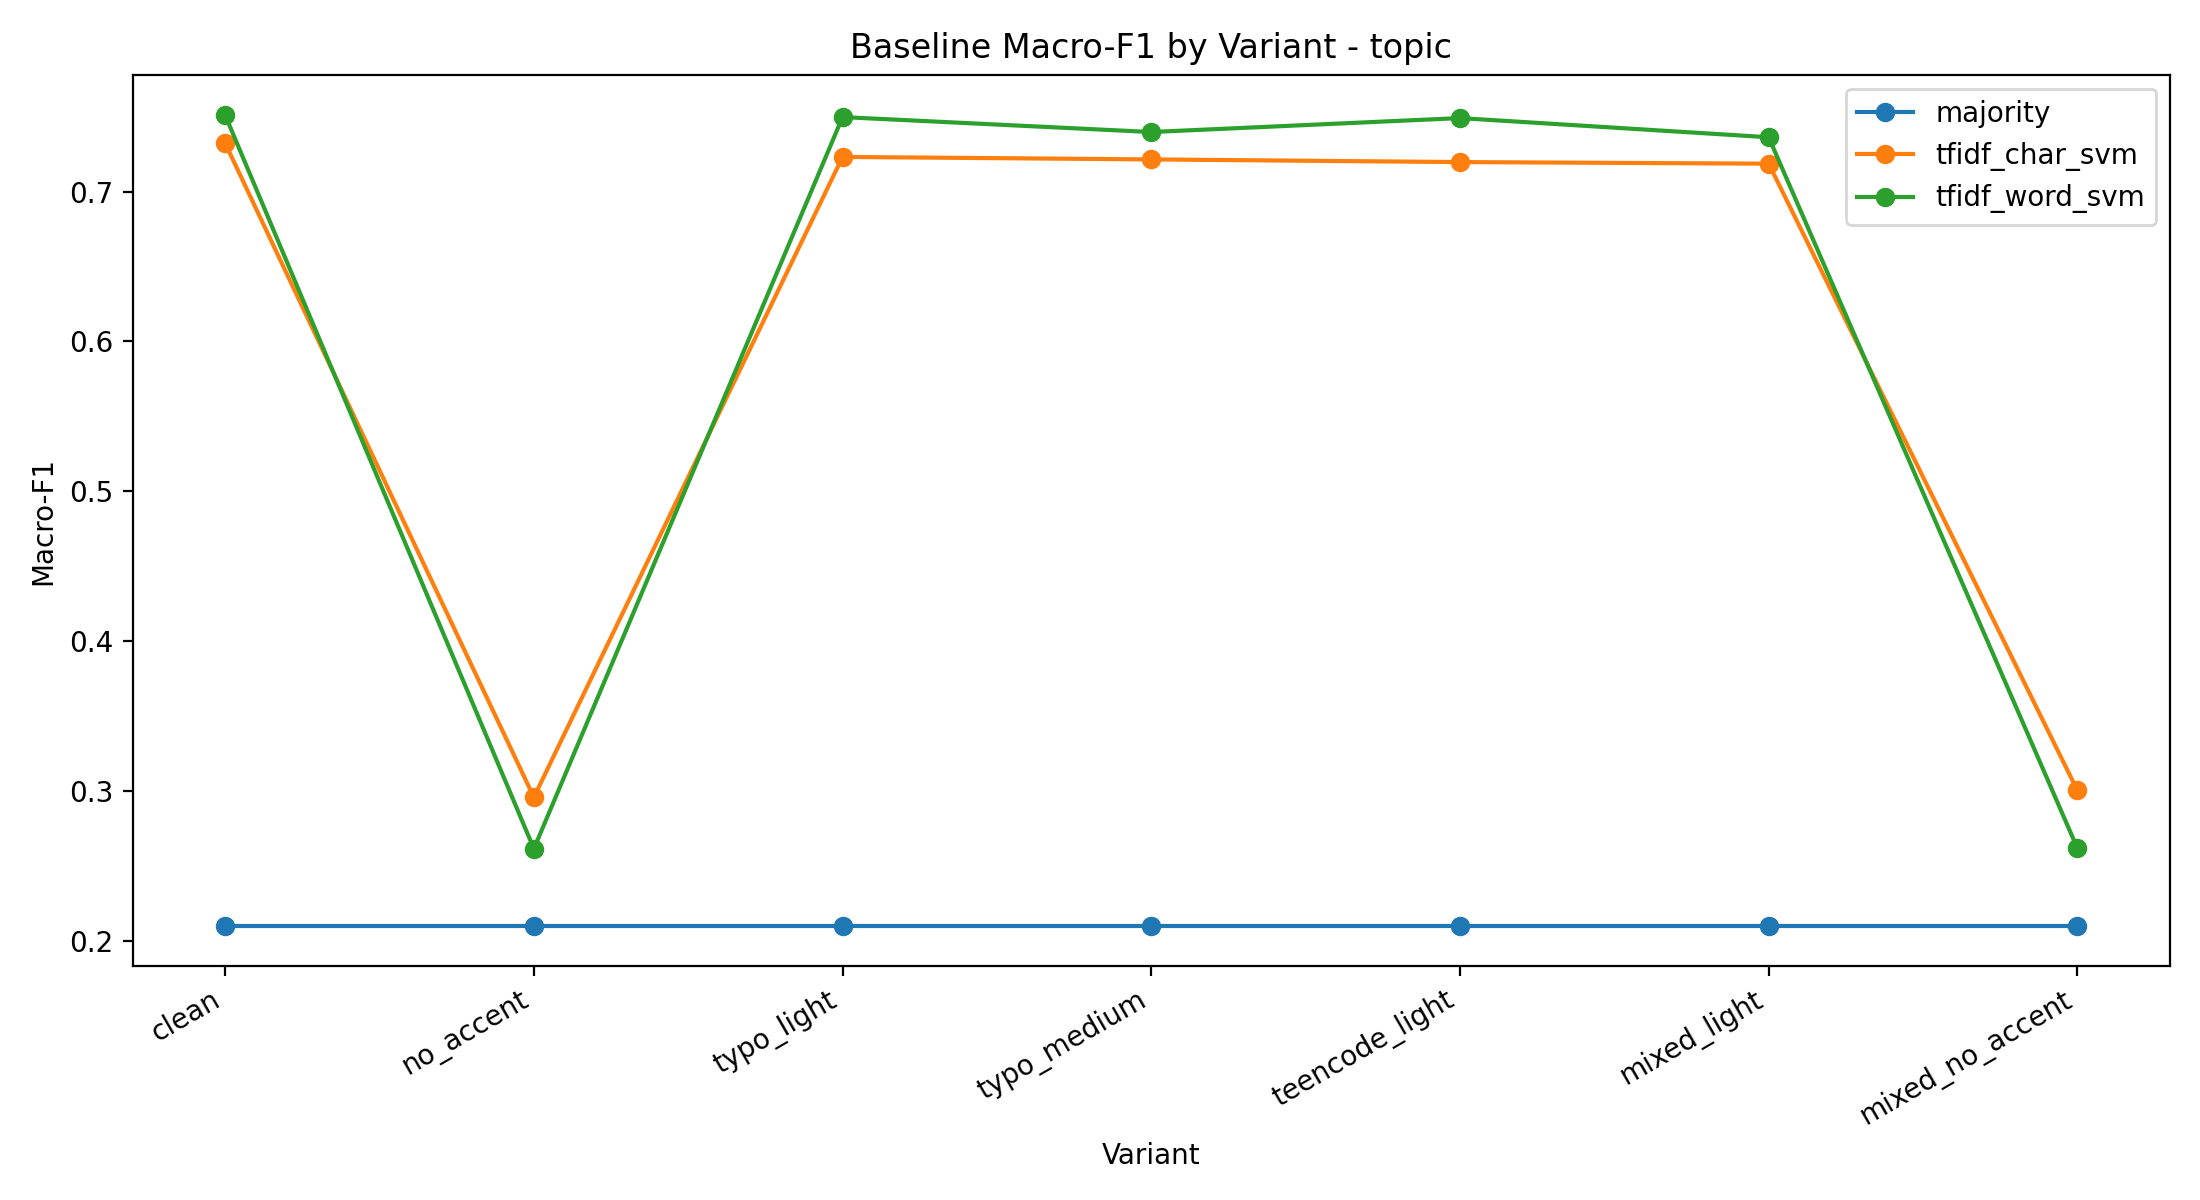

In [4]:
display(Image(filename=str(FIGURES_DIR / "baseline_robustness_macro_f1_sentiment.png")))
display(Image(filename=str(FIGURES_DIR / "baseline_robustness_macro_f1_topic.png")))

## 5. Macro-F1 drop theo variant

Drop được tính theo công thức:

```text
macro_f1_drop = clean_macro_f1 - variant_macro_f1
```

Nếu drop lớn, model kém bền trước loại noise đó.

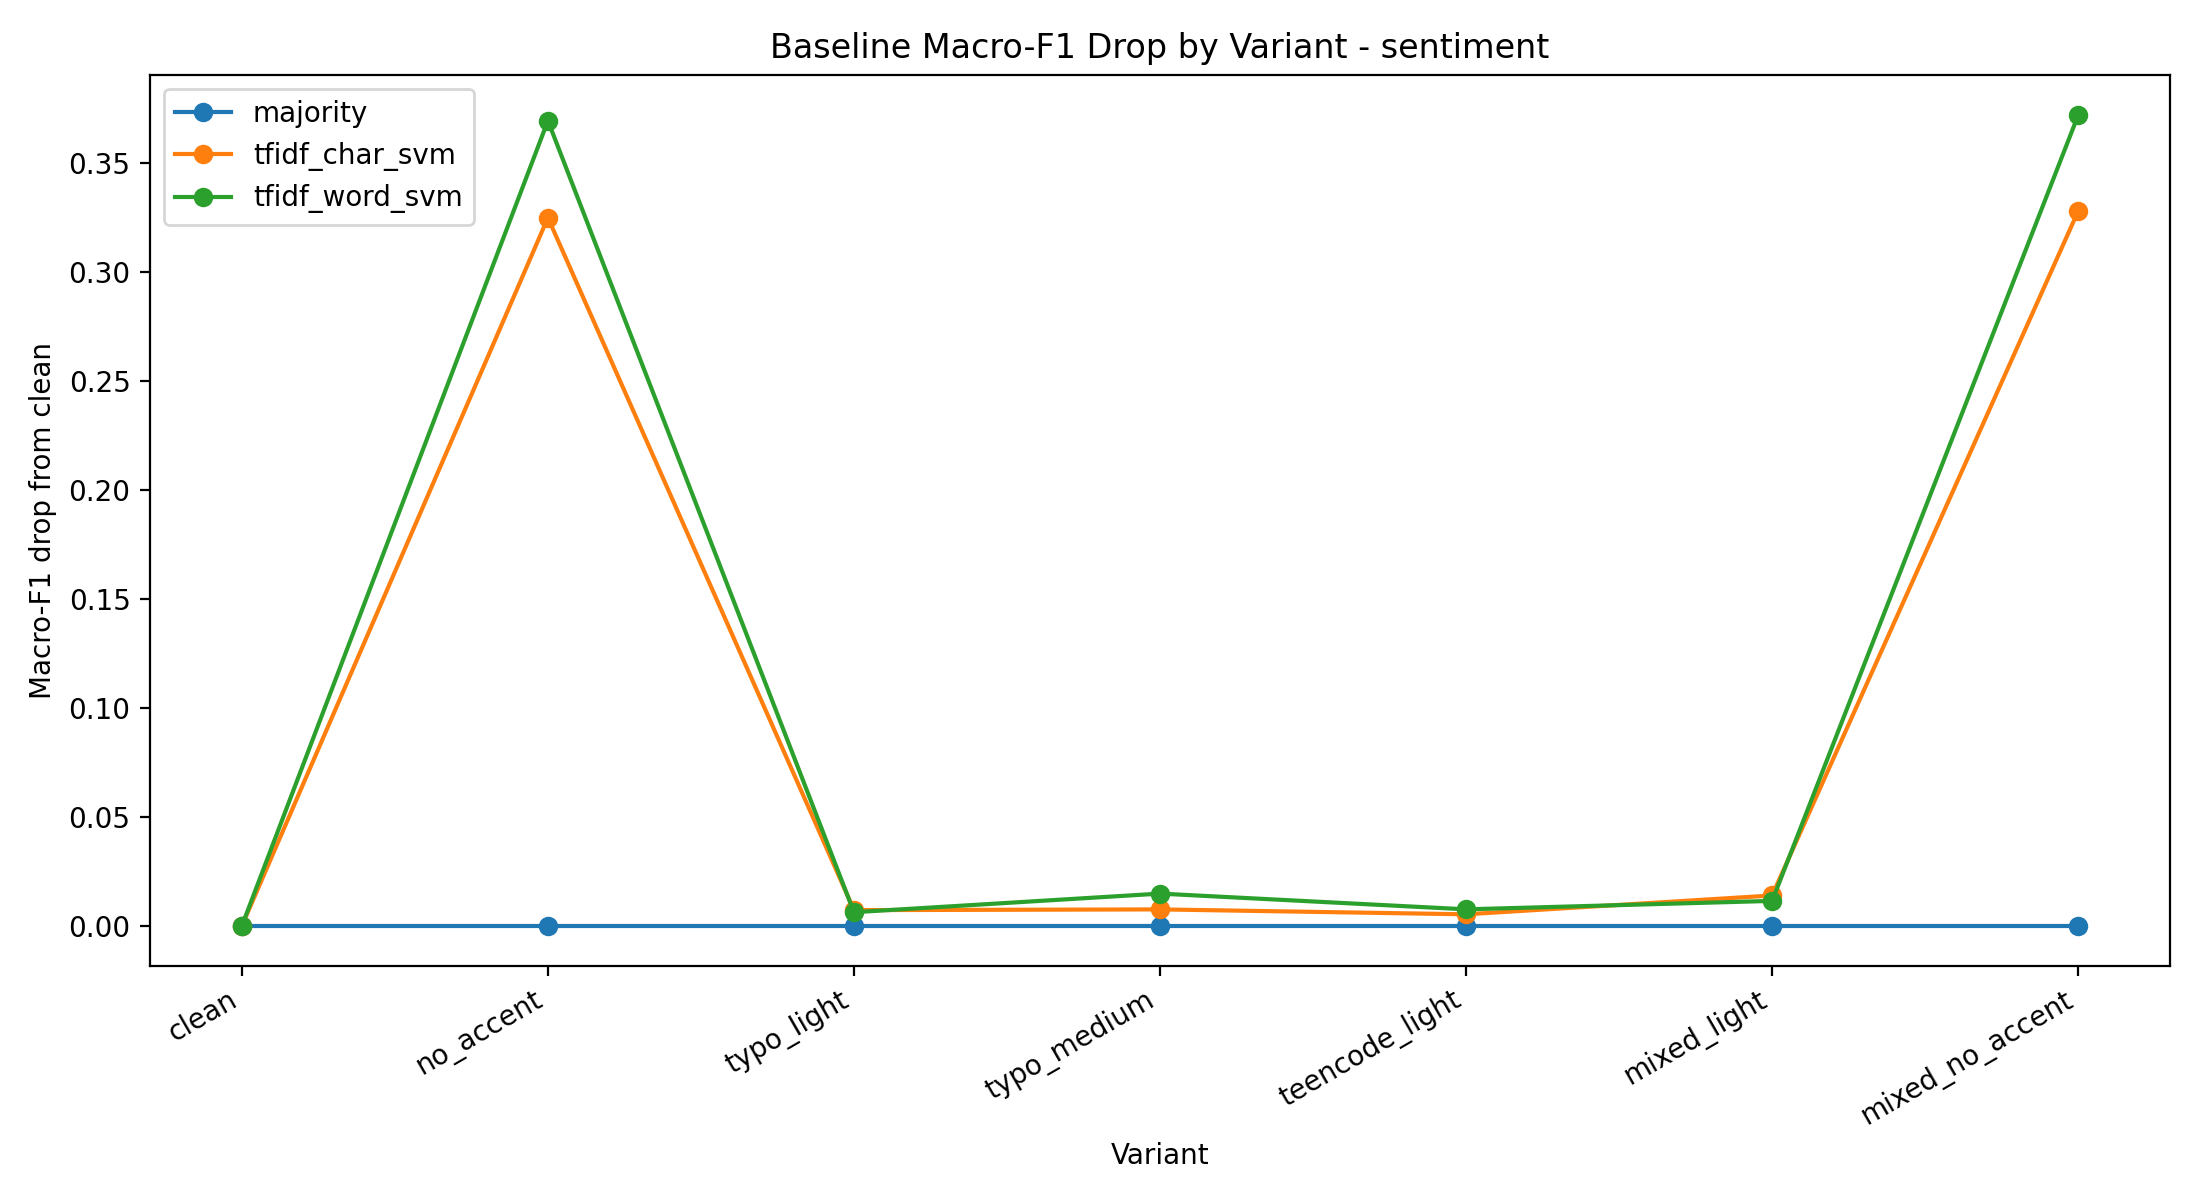

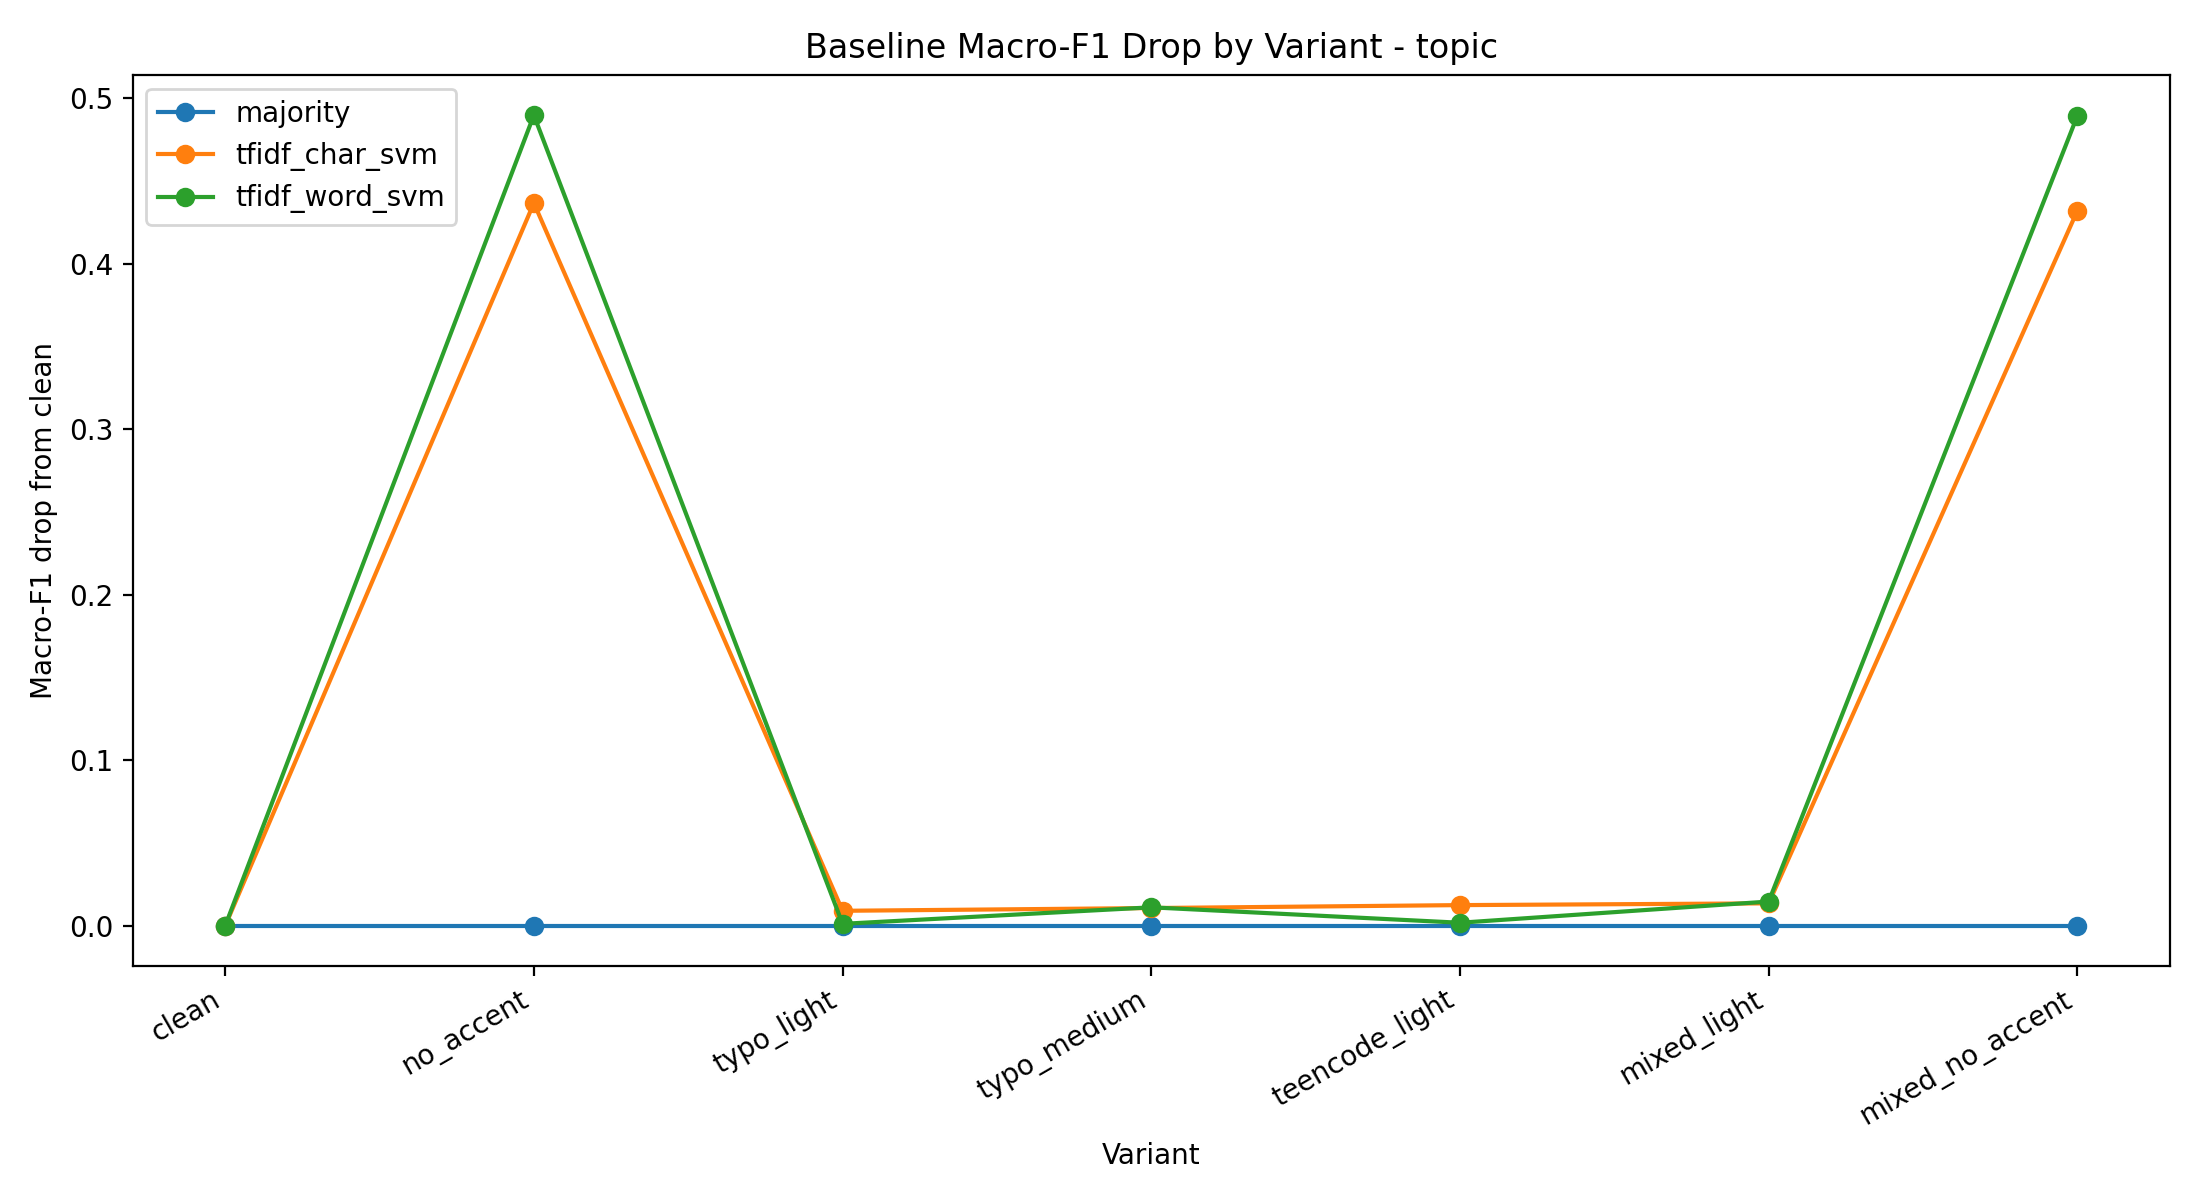

In [5]:
display(Image(filename=str(FIGURES_DIR / "baseline_robustness_macro_f1_drop_sentiment.png")))
display(Image(filename=str(FIGURES_DIR / "baseline_robustness_macro_f1_drop_topic.png")))

## 6. Bảng kết quả tổng hợp

In [6]:
variant_order = [
    "clean",
    "typo_light",
    "typo_medium",
    "teencode_light",
    "mixed_light",
    "no_accent",
    "mixed_no_accent",
]

results_view = results_df.copy()
results_view["variant"] = pd.Categorical(results_view["variant"], categories=variant_order, ordered=True)
results_view = results_view.sort_values(["task", "model", "variant"])

display(results_view)

,task,model,variant,noise_type,noise_level,num_samples,accuracy,macro_f1,weighted_f1
0,sentiment,majority,clean,clean,none,3166,0.502211,0.222876,0.335793
5,sentiment,majority,typo_light,typo,light,3166,0.502211,0.222876,0.335793
6,sentiment,majority,typo_medium,typo,medium,3166,0.502211,0.222876,0.335793
4,sentiment,majority,teencode_light,teencode,light,3166,0.502211,0.222876,0.335793
1,sentiment,majority,mixed_light,mixed,light,3166,0.502211,0.222876,0.335793
3,sentiment,majority,no_accent,remove_diacritics,medium,3166,0.502211,0.222876,0.335793
2,sentiment,majority,mixed_no_accent,mixed,medium,3166,0.502211,0.222876,0.335793
7,sentiment,tfidf_char_svm,clean,clean,none,3166,0.875237,0.738784,0.876528
12,sentiment,tfidf_char_svm,typo_light,typo,light,3166,0.873342,0.731545,0.874915
13,sentiment,tfidf_char_svm,typo_medium,typo,medium,3166,0.870499,0.731212,0.872558


## 7. Bảng drop tổng hợp

In [7]:
drop_view = drop_df.copy()
drop_view["variant"] = pd.Categorical(drop_view["variant"], categories=variant_order, ordered=True)
drop_view = drop_view.sort_values(["task", "model", "variant"])

display(drop_view)

,task,model,variant,noise_type,noise_level,clean_accuracy,variant_accuracy,accuracy_drop,accuracy_relative_drop_percent,clean_macro_f1,variant_macro_f1,macro_f1_drop,macro_f1_relative_drop_percent,clean_weighted_f1,variant_weighted_f1,weighted_f1_drop,weighted_f1_relative_drop_percent
0,sentiment,majority,clean,clean,none,0.502211,0.502211,0.000000,0.0000,0.222876,0.222876,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000
5,sentiment,majority,typo_light,typo,light,0.502211,0.502211,0.000000,0.0000,0.222876,0.222876,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000
6,sentiment,majority,typo_medium,typo,medium,0.502211,0.502211,0.000000,0.0000,0.222876,0.222876,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000
4,sentiment,majority,teencode_light,teencode,light,0.502211,0.502211,0.000000,0.0000,0.222876,0.222876,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000
1,sentiment,majority,mixed_light,mixed,light,0.502211,0.502211,0.000000,0.0000,0.222876,0.222876,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000
3,sentiment,majority,no_accent,remove_diacritics,medium,0.502211,0.502211,0.000000,0.0000,0.222876,0.222876,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000
2,sentiment,majority,mixed_no_accent,mixed,medium,0.502211,0.502211,0.000000,0.0000,0.222876,0.222876,0.000000,0.0000,0.335793,0.335793,0.000000,0.0000
7,sentiment,tfidf_char_svm,clean,clean,none,0.875237,0.875237,0.000000,0.0000,0.738784,0.738784,0.000000,0.0000,0.876528,0.876528,0.000000,0.0000
12,sentiment,tfidf_char_svm,typo_light,typo,light,0.875237,0.873342,0.001895,0.2165,0.738784,0.731545,0.007240,0.9799,0.876528,0.874915,0.001613,0.1840
13,sentiment,tfidf_char_svm,typo_medium,typo,medium,0.875237,0.870499,0.004738,0.5413,0.738784,0.731212,0.007572,1.0250,0.876528,0.872558,0.003969,0.4529


## 8. Clean baseline reference

Mục tiêu: xác định baseline mạnh nhất trên clean test cho từng task.

In [8]:
clean_results = results_df[results_df["variant"] == "clean"].copy()
clean_results = clean_results.sort_values(["task", "macro_f1"], ascending=[True, False])

display(clean_results)

best_clean_by_task = clean_results.groupby("task").head(1).reset_index(drop=True)
display(Markdown("### Best clean baseline by task"))
display(best_clean_by_task)

,task,model,variant,noise_type,noise_level,num_samples,accuracy,macro_f1,weighted_f1
7,sentiment,tfidf_char_svm,clean,clean,none,3166,0.875237,0.738784,0.876528
14,sentiment,tfidf_word_svm,clean,clean,none,3166,0.891977,0.728904,0.887000
0,sentiment,majority,clean,clean,none,3166,0.502211,0.222876,0.335793
35,topic,tfidf_word_svm,clean,clean,none,3166,0.858497,0.750922,0.859847
28,topic,tfidf_char_svm,clean,clean,none,3166,0.833544,0.732207,0.840575
21,topic,majority,clean,clean,none,3166,0.723310,0.209861,0.607178


### Best clean baseline by task

,task,model,variant,noise_type,noise_level,num_samples,accuracy,macro_f1,weighted_f1
0,sentiment,tfidf_char_svm,clean,clean,none,3166,0.875237,0.738784,0.876528
1,topic,tfidf_word_svm,clean,clean,none,3166,0.858497,0.750922,0.859847


## 9. Worst robustness drop

Mục tiêu: xác định noise nào làm từng model giảm mạnh nhất.

In [9]:
worst_drop = (
    drop_df[drop_df["variant"] != "clean"]
    .sort_values(["task", "model", "macro_f1_drop"], ascending=[True, True, False])
    .groupby(["task", "model"])
    .head(1)
    .reset_index(drop=True)
)

display(worst_drop[[
    "task",
    "model",
    "variant",
    "clean_macro_f1",
    "variant_macro_f1",
    "macro_f1_drop",
    "macro_f1_relative_drop_percent",
]])

,task,model,variant,clean_macro_f1,variant_macro_f1,macro_f1_drop,macro_f1_relative_drop_percent
0,sentiment,majority,mixed_light,0.222876,0.222876,0.000000,0.0000
1,sentiment,tfidf_char_svm,mixed_no_accent,0.738784,0.411000,0.327784,44.3680
2,sentiment,tfidf_word_svm,mixed_no_accent,0.728904,0.357145,0.371759,51.0025
3,topic,majority,mixed_light,0.209861,0.209861,0.000000,0.0000
4,topic,tfidf_char_svm,no_accent,0.732207,0.295702,0.436505,59.6150
5,topic,tfidf_word_svm,no_accent,0.750922,0.261359,0.489563,65.1949


## 10. Sentiment robustness analysis

In [10]:
sentiment_results = results_df[results_df["task"] == "sentiment"].copy()
sentiment_drop = drop_df[drop_df["task"] == "sentiment"].copy()

display(Markdown("### Sentiment Macro-F1 by variant"))
display(
    sentiment_results.pivot_table(
        index="variant",
        columns="model",
        values="macro_f1"
    ).reindex(variant_order)
)

display(Markdown("### Sentiment Macro-F1 drop by variant"))
display(
    sentiment_drop.pivot_table(
        index="variant",
        columns="model",
        values="macro_f1_drop"
    ).reindex(variant_order)
)

### Sentiment Macro-F1 by variant

model,majority,tfidf_char_svm,tfidf_word_svm
variant,,,
clean,0.222876,0.738784,0.728904
typo_light,0.222876,0.731545,0.722617
typo_medium,0.222876,0.731212,0.714089
teencode_light,0.222876,0.733458,0.721304
mixed_light,0.222876,0.724830,0.717428
no_accent,0.222876,0.414024,0.359685
mixed_no_accent,0.222876,0.411000,0.357145


### Sentiment Macro-F1 drop by variant

model,majority,tfidf_char_svm,tfidf_word_svm
variant,,,
clean,0.0,0.000000,0.000000
typo_light,0.0,0.007240,0.006287
typo_medium,0.0,0.007572,0.014815
teencode_light,0.0,0.005327,0.007600
mixed_light,0.0,0.013954,0.011476
no_accent,0.0,0.324760,0.369219
mixed_no_accent,0.0,0.327784,0.371759


### Nhận xét sentiment

Các điểm cần ghi nhận:

```text
- TF-IDF char SVM là baseline mạnh nhất trên clean sentiment theo Macro-F1.
- no_accent và mixed_no_accent làm giảm mạnh nhất.
- Char-level SVM bền hơn word-level SVM khi bị mất dấu.
- Với typo/teencode nhẹ, mức giảm nhỏ hơn nhiều so với no_accent.
- Lớp neutral vốn yếu từ clean test, cần tiếp tục theo dõi trong PhoBERT và Error Analysis.
```

## 11. Topic robustness analysis

In [11]:
topic_results = results_df[results_df["task"] == "topic"].copy()
topic_drop = drop_df[drop_df["task"] == "topic"].copy()

display(Markdown("### Topic Macro-F1 by variant"))
display(
    topic_results.pivot_table(
        index="variant",
        columns="model",
        values="macro_f1"
    ).reindex(variant_order)
)

display(Markdown("### Topic Macro-F1 drop by variant"))
display(
    topic_drop.pivot_table(
        index="variant",
        columns="model",
        values="macro_f1_drop"
    ).reindex(variant_order)
)

### Topic Macro-F1 by variant

model,majority,tfidf_char_svm,tfidf_word_svm
variant,,,
clean,0.209861,0.732207,0.750922
typo_light,0.209861,0.723079,0.749665
typo_medium,0.209861,0.721417,0.739693
teencode_light,0.209861,0.719644,0.749003
mixed_light,0.209861,0.718579,0.736205
no_accent,0.209861,0.295702,0.261359
mixed_no_accent,0.209861,0.300282,0.261696


### Topic Macro-F1 drop by variant

model,majority,tfidf_char_svm,tfidf_word_svm
variant,,,
clean,0.0,0.000000,0.000000
typo_light,0.0,0.009128,0.001258
typo_medium,0.0,0.010790,0.011230
teencode_light,0.0,0.012563,0.001919
mixed_light,0.0,0.013628,0.014717
no_accent,0.0,0.436505,0.489563
mixed_no_accent,0.0,0.431925,0.489226


### Nhận xét topic

Các điểm cần ghi nhận:

```text
- TF-IDF word SVM là baseline mạnh nhất trên clean topic.
- Với clean và noise nhẹ, word-level SVM thường tốt hơn char-level SVM.
- Khi mất dấu, char-level SVM bền hơn word-level SVM.
- no_accent và mixed_no_accent làm topic giảm rất mạnh.
- Topic phụ thuộc nhiều vào từ khóa nội dung nên word-level TF-IDF bị ảnh hưởng nặng khi token bị mất dấu.
- Lớp others và các lớp nhỏ cần được phân tích kỹ ở Error Analysis.
```

## 12. Per-class analysis trên clean và no_accent

Mục tiêu: kiểm tra lớp nào giảm mạnh nhất khi bỏ dấu.

In [12]:
summary_labels = {"accuracy", "macro avg", "weighted avg"}

per_class = class_report_df[
    ~class_report_df["label"].isin(summary_labels)
].copy()

focus_variants = ["clean", "no_accent", "mixed_no_accent"]
per_class_focus = per_class[per_class["variant"].isin(focus_variants)].copy()

display(per_class_focus.sort_values(["task", "model", "label", "variant"]))

# So sánh clean vs no_accent theo F1
clean_pc = per_class[per_class["variant"] == "clean"][
    ["task", "model", "label", "f1_score"]
].rename(columns={"f1_score": "clean_f1"})

no_accent_pc = per_class[per_class["variant"] == "no_accent"][
    ["task", "model", "label", "f1_score"]
].rename(columns={"f1_score": "no_accent_f1"})

pc_drop = clean_pc.merge(no_accent_pc, on=["task", "model", "label"], how="inner")
pc_drop["f1_drop"] = pc_drop["clean_f1"] - pc_drop["no_accent_f1"]
pc_drop["relative_f1_drop_percent"] = pc_drop.apply(
    lambda row: 0.0 if row["clean_f1"] == 0 else round(row["f1_drop"] / row["clean_f1"] * 100, 4),
    axis=1,
)

display(Markdown("### Per-class F1 drop: clean → no_accent"))
display(pc_drop.sort_values("f1_drop", ascending=False))

,task,model,variant,label,precision,recall,f1_score,support
0,sentiment,majority,clean,negative,0.000000,0.000000,0.000000,1409.0
36,sentiment,majority,mixed_no_accent,negative,0.000000,0.000000,0.000000,1409.0
6,sentiment,majority,no_accent,negative,0.000000,0.000000,0.000000,1409.0
1,sentiment,majority,clean,neutral,0.000000,0.000000,0.000000,167.0
37,sentiment,majority,mixed_no_accent,neutral,0.000000,0.000000,0.000000,167.0
...,...,...,...,...,...,...,...,...
220,topic,tfidf_word_svm,mixed_no_accent,others,0.063084,0.679245,0.115446,159.0
185,topic,tfidf_word_svm,no_accent,others,0.063239,0.672956,0.115613,159.0
176,topic,tfidf_word_svm,clean,training_program,0.672282,0.767483,0.716735,572.0
218,topic,tfidf_word_svm,mixed_no_accent,training_program,0.349099,0.270979,0.305118,572.0


### Per-class F1 drop: clean → no_accent

,task,model,label,clean_f1,no_accent_f1,f1_drop,relative_f1_drop_percent
15,topic,tfidf_word_svm,facility,0.914676,0.159091,0.755585,82.6069
19,topic,tfidf_char_svm,facility,0.886667,0.198198,0.688468,77.6468
5,sentiment,tfidf_word_svm,positive,0.920281,0.428019,0.492262,53.4904
13,topic,tfidf_word_svm,lecturer,0.920452,0.468293,0.452159,49.1236
18,topic,tfidf_char_svm,training_program,0.675388,0.245266,0.430122,63.6852
14,topic,tfidf_word_svm,training_program,0.716735,0.302439,0.414296,57.8032
3,sentiment,tfidf_word_svm,negative,0.912641,0.505051,0.407591,44.6606
6,sentiment,tfidf_char_svm,negative,0.893781,0.532915,0.360865,40.3751
8,sentiment,tfidf_char_svm,positive,0.909965,0.552295,0.357670,39.3059
16,topic,tfidf_word_svm,others,0.451827,0.115613,0.336214,74.4121


## 13. Best baseline trên từng variant

Mục tiêu: chọn baseline đối chứng mạnh nhất cho từng điều kiện test.

In [13]:
best_by_variant = (
    results_df.sort_values(["task", "variant", "macro_f1"], ascending=[True, True, False])
    .groupby(["task", "variant"])
    .head(1)
    .reset_index(drop=True)
)

best_by_variant["variant"] = pd.Categorical(best_by_variant["variant"], categories=variant_order, ordered=True)
best_by_variant = best_by_variant.sort_values(["task", "variant"])

display(best_by_variant[[
    "task",
    "variant",
    "model",
    "accuracy",
    "macro_f1",
    "weighted_f1",
]])

,task,variant,model,accuracy,macro_f1,weighted_f1
0,sentiment,clean,tfidf_char_svm,0.875237,0.738784,0.876528
5,sentiment,typo_light,tfidf_char_svm,0.873342,0.731545,0.874915
6,sentiment,typo_medium,tfidf_char_svm,0.870499,0.731212,0.872558
4,sentiment,teencode_light,tfidf_char_svm,0.869236,0.733458,0.871656
1,sentiment,mixed_light,tfidf_char_svm,0.864498,0.724830,0.867596
3,sentiment,no_accent,tfidf_char_svm,0.474416,0.414024,0.522812
2,sentiment,mixed_no_accent,tfidf_char_svm,0.469678,0.411000,0.519813
7,topic,clean,tfidf_word_svm,0.858497,0.750922,0.859847
12,topic,typo_light,tfidf_word_svm,0.855338,0.749665,0.857454
13,topic,typo_medium,tfidf_word_svm,0.848705,0.739693,0.851713


## 14. Kết luận Stage 5

Kết luận chính:

```text
1. Baseline truyền thống tương đối ổn định trước typo, teencode và mixed_light.
2. Bỏ dấu tiếng Việt là loại noise gây suy giảm mạnh nhất.
3. mixed_no_accent có tác động gần giống no_accent, cho thấy bỏ dấu là yếu tố phá hủy chính.
4. Char-level SVM bền hơn word-level SVM trong điều kiện mất dấu.
5. Word-level SVM vẫn mạnh hơn trên clean và một số noise nhẹ, đặc biệt với topic classification.
6. Majority baseline không đổi theo noise vì luôn dự đoán lớp đa số, nên không dùng để kết luận về robustness.
```

Mốc so sánh cho PhoBERT:

```text
Sentiment:
- Clean: so với TF-IDF char SVM
- No-accent / mixed-no-accent: so với TF-IDF char SVM

Topic:
- Clean: so với TF-IDF word SVM
- No-accent / mixed-no-accent: so với TF-IDF char SVM
```

In [14]:
display(Markdown("### Final clean baseline reference"))
display(best_clean_by_task)

display(Markdown("### Final best baseline by variant"))
display(best_by_variant[[
    "task",
    "variant",
    "model",
    "macro_f1",
    "accuracy",
]])

### Final clean baseline reference

,task,model,variant,noise_type,noise_level,num_samples,accuracy,macro_f1,weighted_f1
0,sentiment,tfidf_char_svm,clean,clean,none,3166,0.875237,0.738784,0.876528
1,topic,tfidf_word_svm,clean,clean,none,3166,0.858497,0.750922,0.859847


### Final best baseline by variant

,task,variant,model,macro_f1,accuracy
0,sentiment,clean,tfidf_char_svm,0.738784,0.875237
5,sentiment,typo_light,tfidf_char_svm,0.731545,0.873342
6,sentiment,typo_medium,tfidf_char_svm,0.731212,0.870499
4,sentiment,teencode_light,tfidf_char_svm,0.733458,0.869236
1,sentiment,mixed_light,tfidf_char_svm,0.724830,0.864498
3,sentiment,no_accent,tfidf_char_svm,0.414024,0.474416
2,sentiment,mixed_no_accent,tfidf_char_svm,0.411000,0.469678
7,topic,clean,tfidf_word_svm,0.750922,0.858497
12,topic,typo_light,tfidf_word_svm,0.749665,0.855338
13,topic,typo_medium,tfidf_word_svm,0.739693,0.848705


## 15. Stage 5 status

Stage 5 hoàn thành khi có đủ:

```text
outputs/tables/baseline_robustness_results.csv
outputs/tables/baseline_robustness_drop.csv
outputs/tables/baseline_robustness_class_report.csv
outputs/predictions/baseline_robustness_predictions.csv
outputs/figures/baseline_robustness_macro_f1_sentiment.png
outputs/figures/baseline_robustness_macro_f1_topic.png
outputs/figures/baseline_robustness_macro_f1_drop_sentiment.png
outputs/figures/baseline_robustness_macro_f1_drop_topic.png
outputs/reports/baseline_robustness_report.md
```

Giai đoạn tiếp theo:

```text
Stage 6 — PhoBERT Fine-tuning on Kaggle
```

Mục tiêu Stage 6:

```text
- Fine-tune PhoBERT cho sentiment.
- Fine-tune PhoBERT cho topic.
- Evaluate clean test.
- Sau đó evaluate cùng noisy variants để so với baseline robustness.
```